<a href="https://colab.research.google.com/github/Kavia-M/Data_science_course-Intellipaat/blob/main/Python/Assignments/Assignment_Quiz/Decision_Tree_Assignment_Quiz.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Problem Statement:

1. Pokémon is a group of adorable creatures peacefully colonizing a planet until humans come along and make them combat each other in order to get shiny badges and we can call them Pokémon masters.

2. In this universe, there exists a group of rare and often strong Pokémon, known as Legendary Pokémon. Unfortunately, there are no detailed criteria that define these Pokémon.

3. The only way to recognize a Legendary Pokémon is through information from official media, such as the game or anime.

4. This data set includes 721 Pokemon, including their number, name, first and second type, and basic stats: HP, Attack, Defense, Special Attack, Special Defense, and Speed. The legend of a pokemon cannot be suspected only by its Attack and Defense. It would be worth finding which variables can define the legend of a pokemon. The strategy is to analyze the data and perform a predictive task of classification to predict the legend of a pokemon using a decision tree algorithm.

**DATA DESCRIPTION:**

| Column Names | Description |
|--------------|---------------------------------------------------------------------------------------------|
| ID           | ID of each Pokemon                                                                          |
| Name         | Name of each Pokemon                                                                        |
| Type 1       | Each Pokemon has a type, this determines weakness/resistance to attacks                     |
| Type 2       | Some Pokemon are dual type and have 2                                                       |
| Total        | sum of all stats that come after this, a general guide to how strong a Pokemon is            |
| HP           | hit points, or health, defines how much damage a Pokemon can withstand before fainting       |
| Attack       | the base modifier for normal attacks (eg. Scratch, Punch)                                   |
| Defense      | the base damage resistance against normal attacks                                           |
| SP Atk       | special attack, the base modifier for special attacks (e.g. fire blast, bubble beam)        |
| SP Def       | the base damage resistance against special attacks                                          |
| Speed        | determines which Pokemon attacks first each round                                           |
| Generation   | type of generation of the Pokemon                                                           |
| Legendary    | Rare Pokemon                                                                                |


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pokemon = pd.read_csv('/content/Pokemon.csv')

In [3]:
pokemon

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,719,Diancie,Rock,Fairy,600,50,100,150,100,150,50,6,True
796,719,DiancieMega Diancie,Rock,Fairy,700,50,160,110,160,110,110,6,True
797,720,HoopaHoopa Confined,Psychic,Ghost,600,80,110,60,150,130,70,6,True
798,720,HoopaHoopa Unbound,Psychic,Dark,680,80,160,60,170,130,80,6,True


In [4]:
pokemon.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   #           800 non-null    int64 
 1   Name        800 non-null    object
 2   Type 1      800 non-null    object
 3   Type 2      414 non-null    object
 4   Total       800 non-null    int64 
 5   HP          800 non-null    int64 
 6   Attack      800 non-null    int64 
 7   Defense     800 non-null    int64 
 8   Sp. Atk     800 non-null    int64 
 9   Sp. Def     800 non-null    int64 
 10  Speed       800 non-null    int64 
 11  Generation  800 non-null    int64 
 12  Legendary   800 non-null    bool  
dtypes: bool(1), int64(9), object(3)
memory usage: 75.9+ KB


In [5]:
pokemon['Name'].unique()

array(['Bulbasaur', 'Ivysaur', 'Venusaur', 'VenusaurMega Venusaur',
       'Charmander', 'Charmeleon', 'Charizard',
       'CharizardMega Charizard X', 'CharizardMega Charizard Y',
       'Squirtle', 'Wartortle', 'Blastoise', 'BlastoiseMega Blastoise',
       'Caterpie', 'Metapod', 'Butterfree', 'Weedle', 'Kakuna',
       'Beedrill', 'BeedrillMega Beedrill', 'Pidgey', 'Pidgeotto',
       'Pidgeot', 'PidgeotMega Pidgeot', 'Rattata', 'Raticate', 'Spearow',
       'Fearow', 'Ekans', 'Arbok', 'Pikachu', 'Raichu', 'Sandshrew',
       'Sandslash', 'Nidoran♀', 'Nidorina', 'Nidoqueen', 'Nidoran♂',
       'Nidorino', 'Nidoking', 'Clefairy', 'Clefable', 'Vulpix',
       'Ninetales', 'Jigglypuff', 'Wigglytuff', 'Zubat', 'Golbat',
       'Oddish', 'Gloom', 'Vileplume', 'Paras', 'Parasect', 'Venonat',
       'Venomoth', 'Diglett', 'Dugtrio', 'Meowth', 'Persian', 'Psyduck',
       'Golduck', 'Mankey', 'Primeape', 'Growlithe', 'Arcanine',
       'Poliwag', 'Poliwhirl', 'Poliwrath', 'Abra', 'Kadabra',

In [6]:
pokemon['Type 1'].value_counts()

,count
Type 1,
Water,112
Normal,98
Grass,70
Bug,69
Psychic,57
Fire,52
Rock,44
Electric,44
Ground,32


In [8]:
pokemon['Type 2'].value_counts()

,count
Type 2,
Flying,97
Ground,35
Poison,34
Psychic,33
Fighting,26
Grass,25
Fairy,23
Steel,22
Dark,20


1) How many pokemon are from the 5th generation?
- 178
- 165
- 170
- 150

In [9]:
pokemon['Generation'].value_counts()

,count
Generation,
1,166
5,165
3,160
4,121
2,106
6,82


In [10]:
pokemon['Generation'].value_counts().get(5)

np.int64(165)

In [13]:
pokemon[pokemon['Generation']==5].count()

,0
#,165
Name,165
Type 1,165
Type 2,82
Total,165
HP,165
Attack,165
Defense,165
Sp. Atk,165
Sp. Def,165


In [14]:
len(pokemon[pokemon['Generation']==5])

165

1. Answer - 165

2) How many pokemon have the highest defense score?
- 3
- 2
- 10
- 7

In [15]:
pokemon['Defense'].max()

230

In [16]:
pokemon['Defense'].value_counts().sort_index(ascending=False)

,count
Defense,
230,3
200,2
184,1
180,3
168,1
...,...
23,1
20,4
15,4


In [17]:
len(pokemon[pokemon['Defense']==pokemon['Defense'].max()])

3

230 is Maximum Defense and 3 pokemon has it

2. Answer - 3

3) How you will be handling missing values (?) in this dataset:
- Fill up the null values with standard deviation.
- Fill up the null values with the mean.
- Fill up the null values with NaN.
- Fill up the null values with the median.

In [21]:
(pokemon == '?').any()

,0
#,False
Name,False
Type 1,False
Type 2,False
Total,False
HP,False
Attack,False
Defense,False
Sp. Atk,False
Sp. Def,False


In [22]:
(pokemon == '?').any().any()

np.False_

In [19]:
(pokemon == '?').sum()

,0
#,0
Name,0
Type 1,0
Type 2,0
Total,0
HP,0
Attack,0
Defense,0
Sp. Atk,0
Sp. Def,0


In [23]:
(pokemon == '?').sum().sum()

np.int64(0)

Usually replace missing values with Nan and then fill Nan with mean for numeric values and mode for categorical values

In [24]:
diabetics = pd.read_csv('/content/diabetes.csv')

In [25]:
diabetics.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [26]:
(diabetics == '?').any().any()

np.False_

3. Answer - Fill up the null values with NaN.

4) Which column of the following column is having negative relationship with the generation column?
- None of the above
- Attack
- Both of the above
- Speed

In [30]:
pokemon.dtypes

,0
#,int64
Name,object
Type 1,object
Type 2,object
Total,int64
HP,int64
Attack,int64
Defense,int64
Sp. Atk,int64
Sp. Def,int64


In [29]:
pokemon.dtypes != 'object'

,0
#,True
Name,False
Type 1,False
Type 2,False
Total,True
HP,True
Attack,True
Defense,True
Sp. Atk,True
Sp. Def,True


In [28]:
pokemon.columns[pokemon.dtypes != 'object']

Index(['#', 'Total', 'HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed',
       'Generation', 'Legendary'],
      dtype='object')

In [31]:
pokemon[pokemon.columns[pokemon.dtypes != 'object']]

,#,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,318,45,49,49,65,65,45,1,False
1,2,405,60,62,63,80,80,60,1,False
2,3,525,80,82,83,100,100,80,1,False
3,3,625,80,100,123,122,120,80,1,False
4,4,309,39,52,43,60,50,65,1,False
...,...,...,...,...,...,...,...,...,...,...
795,719,600,50,100,150,100,150,50,6,True
796,719,700,50,160,110,160,110,110,6,True
797,720,600,80,110,60,150,130,70,6,True
798,720,680,80,160,60,170,130,80,6,True


In [32]:
pokemon[pokemon.columns[pokemon.dtypes != 'object']].corr()

,#,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
#,1.000000,0.119813,0.097614,0.102298,0.094786,0.088759,0.085817,0.010733,0.982516,0.153396
Total,0.119813,1.000000,0.618748,0.736211,0.612787,0.747250,0.717609,0.575943,0.048384,0.501758
HP,0.097614,0.618748,1.000000,0.422386,0.239622,0.362380,0.378718,0.175952,0.058683,0.273620
Attack,0.102298,0.736211,0.422386,1.000000,0.438687,0.396362,0.263990,0.381240,0.051451,0.345408
Defense,0.094786,0.612787,0.239622,0.438687,1.000000,0.223549,0.510747,0.015227,0.042419,0.246377
Sp. Atk,0.088759,0.747250,0.362380,0.396362,0.223549,1.000000,0.506121,0.473018,0.036437,0.448907
Sp. Def,0.085817,0.717609,0.378718,0.263990,0.510747,0.506121,1.000000,0.259133,0.028486,0.363937
Speed,0.010733,0.575943,0.175952,0.381240,0.015227,0.473018,0.259133,1.000000,-0.023121,0.326715
Generation,0.982516,0.048384,0.058683,0.051451,0.042419,0.036437,0.028486,-0.023121,1.000000,0.079794
Legendary,0.153396,0.501758,0.273620,0.345408,0.246377,0.448907,0.363937,0.326715,0.079794,1.000000


In [34]:
pokemon[[col for col in pokemon.columns if pokemon[col].dtype!='object']].corr()

,#,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
#,1.000000,0.119813,0.097614,0.102298,0.094786,0.088759,0.085817,0.010733,0.982516,0.153396
Total,0.119813,1.000000,0.618748,0.736211,0.612787,0.747250,0.717609,0.575943,0.048384,0.501758
HP,0.097614,0.618748,1.000000,0.422386,0.239622,0.362380,0.378718,0.175952,0.058683,0.273620
Attack,0.102298,0.736211,0.422386,1.000000,0.438687,0.396362,0.263990,0.381240,0.051451,0.345408
Defense,0.094786,0.612787,0.239622,0.438687,1.000000,0.223549,0.510747,0.015227,0.042419,0.246377
Sp. Atk,0.088759,0.747250,0.362380,0.396362,0.223549,1.000000,0.506121,0.473018,0.036437,0.448907
Sp. Def,0.085817,0.717609,0.378718,0.263990,0.510747,0.506121,1.000000,0.259133,0.028486,0.363937
Speed,0.010733,0.575943,0.175952,0.381240,0.015227,0.473018,0.259133,1.000000,-0.023121,0.326715
Generation,0.982516,0.048384,0.058683,0.051451,0.042419,0.036437,0.028486,-0.023121,1.000000,0.079794
Legendary,0.153396,0.501758,0.273620,0.345408,0.246377,0.448907,0.363937,0.326715,0.079794,1.000000


In [35]:
correlation_matrix = pokemon[pokemon.columns[pokemon.dtypes != 'object']].corr()

In [36]:
correlation_matrix['Generation']

,Generation
#,0.982516
Total,0.048384
HP,0.058683
Attack,0.051451
Defense,0.042419
Sp. Atk,0.036437
Sp. Def,0.028486
Speed,-0.023121
Generation,1.000000
Legendary,0.079794


In [37]:
type(correlation_matrix)

pandas.core.frame.DataFrame

In [42]:
correlation_matrix['Generation']<0 # use this as condition to filter

,Generation
#,False
Total,False
HP,False
Attack,False
Defense,False
Sp. Atk,False
Sp. Def,False
Speed,True
Generation,False
Legendary,False


In [47]:
neg_index = correlation_matrix['Generation'][correlation_matrix['Generation']<0].index

In [45]:
pos_index = correlation_matrix['Generation'][correlation_matrix['Generation']>0].index

In [46]:
pos_index

Index(['#', 'Total', 'HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def',
       'Generation', 'Legendary'],
      dtype='object')

In [48]:
neg_index

Index(['Speed'], dtype='object')

4. Answer - Speed

5)
Q5. Which of the following model we can use for predicting the legendary of the pokemon?
- Logistic Regression
- Decision Tree Model
- All of the Above
- Random Forest Model

Legendary is a binary categorical column TRUE or FALSE,

so any calssification model can be used.

Logistic Regression (simple logistic regression) is for Binary classification so this can be used

Decision Tree can do both classification and regression DecisionTreeClassifier model can be used

Random Forest is ensemble version of Decision Tree, so this also can be used.

5. Answer - All of the Above

6) Build a Decision Tree Model for the given data considering "Legendary" as Target Column:

  - 1. Handle the missing values.
  - 2. Split the dataset into a 70:30 ratio with random state as 1.

What is the precision of the Decision Tree model when the target is False?

- 0.50 to 0.60
- 0.80 to 0.90
- 0.90 to 1.0
- 1.0 to 2.0

#### Step 1 - Handle the missing values

In [49]:
# already checked for ?
# now we shall check for space or blank string

(pokemon == '').any()

,0
#,False
Name,False
Type 1,False
Type 2,False
Total,False
HP,False
Attack,False
Defense,False
Sp. Atk,False
Sp. Def,False


In [50]:
(pokemon == '').any().any()

np.False_

In [51]:
(pokemon == ' ').any()

,0
#,False
Name,False
Type 1,False
Type 2,False
Total,False
HP,False
Attack,False
Defense,False
Sp. Atk,False
Sp. Def,False


In [53]:
pokemon['Type 2'].value_counts().sum()

np.int64(414)

In [54]:
len(pokemon)

800

In [57]:
pokemon.isnull().sum()

,0
#,0
Name,0
Type 1,0
Type 2,386
Total,0
HP,0
Attack,0
Defense,0
Sp. Atk,0
Sp. Def,0


In [59]:
pokemon.isnull().sum()[pokemon.isnull().sum()>0]

,0
Type 2,386


In [63]:
columns_with_null = pokemon.isnull().sum()[pokemon.isnull().sum()>0].index

In [62]:
pokemon.isnull().sum()[pokemon.isnull().sum()>0].index[0]

'Type 2'

In [66]:
pokemon[columns_with_null].dtypes

,0
Type 2,object


object means we need to fill with mode if it has more than 30% null values

In [68]:
pokemon.isnull().sum()[columns_with_null] / len(pokemon) * 100

,0
Type 2,48.25


In [69]:
# 48% null, so we need to fill with mode

In [70]:
pokemon[columns_with_null].mode()

,Type 2
0,Flying


From chatgpt for automating the null filling

```python
columns_with_null = pokemon.isnull().sum()[pokemon.isnull().sum() > 0].index

for col in columns_with_null:
    null_percent = pokemon[col].isnull().sum() / len(pokemon) * 100
    
    if null_percent > 30:
        # Fill based on dtype
        if pokemon[col].dtype == 'object':
            mode_value = pokemon[col].mode()[0]
            pokemon[col].fillna(mode_value, inplace=True)
            print(f"Filling column '{col}' with mode: {mode_value}")
        else:
            mean_value = pokemon[col].mean()
            pokemon[col].fillna(mean_value, inplace=True)
            print(f"Filling column '{col}' with mean: {mean_value:.2f}")
    else:
        # Drop rows with missing values in this column
        pokemon.dropna(subset=[col], inplace=True)
        print(f"Dropping rows with missing values in column '{col}'")

```



In [71]:
null_percent = pokemon['Type 2'].isnull().sum() / len(pokemon) * 100

In [73]:
null_percent

np.float64(48.25)

In [76]:
pokemon[columns_with_null].mode()[columns_with_null[0]][0]

'Flying'

In [78]:
# since we have only 1 column with null , I am doing it directly

In [77]:
pokemon[columns_with_null[0]].mode()[0]

'Flying'

In [79]:
mode_value = pokemon[columns_with_null[0]].mode()[0]

In [80]:
pokemon[columns_with_null[0]].fillna(mode_value, inplace=True)

/tmp/ipython-input-1536529750.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  pokemon[columns_with_null[0]].fillna(mode_value, inplace=True)


In [84]:
# already filled but for safety, we are doign again, the below line won't make any change
pokemon.fillna({columns_with_null[0]: mode_value}, inplace=True)

In [85]:
pokemon.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   #           800 non-null    int64 
 1   Name        800 non-null    object
 2   Type 1      800 non-null    object
 3   Type 2      800 non-null    object
 4   Total       800 non-null    int64 
 5   HP          800 non-null    int64 
 6   Attack      800 non-null    int64 
 7   Defense     800 non-null    int64 
 8   Sp. Atk     800 non-null    int64 
 9   Sp. Def     800 non-null    int64 
 10  Speed       800 non-null    int64 
 11  Generation  800 non-null    int64 
 12  Legendary   800 non-null    bool  
dtypes: bool(1), int64(9), object(3)
memory usage: 75.9+ KB


In [86]:
len(pokemon)

800

In [87]:
pokemon.isnull().sum()

,0
#,0
Name,0
Type 1,0
Type 2,0
Total,0
HP,0
Attack,0
Defense,0
Sp. Atk,0
Sp. Def,0


In [88]:
pokemon.isnull().sum().sum()

np.int64(0)

In [104]:
pokemon.duplicated().sum()

np.int64(0)

#### Step 2 - Split the dataset into a 70:30 ratio with random state as 1.

In [89]:
from sklearn.model_selection import train_test_split

from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score

from sklearn.tree import DecisionTreeClassifier

In [105]:
len(pokemon['#'].unique())

721

In [110]:
pokemon['#'].duplicated().sum()

np.int64(79)

In [108]:
len(pokemon['Name'].unique())

800

In [111]:
pokemon['Name'].duplicated().sum()

np.int64(0)

In [114]:
# no need # id also, only few duplicate id existing, name also all are unique
# we can trace back using index since index is not replaced in train test split
X_pokemon = pokemon.drop(['#', 'Name', 'Legendary'], axis=1)

In [115]:
X_pokemon

,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation
0,Grass,Poison,318,45,49,49,65,65,45,1
1,Grass,Poison,405,60,62,63,80,80,60,1
2,Grass,Poison,525,80,82,83,100,100,80,1
3,Grass,Poison,625,80,100,123,122,120,80,1
4,Fire,Flying,309,39,52,43,60,50,65,1
...,...,...,...,...,...,...,...,...,...,...
795,Rock,Fairy,600,50,100,150,100,150,50,6
796,Rock,Fairy,700,50,160,110,160,110,110,6
797,Psychic,Ghost,600,80,110,60,150,130,70,6
798,Psychic,Dark,680,80,160,60,170,130,80,6


In [116]:
y_pokemon = pokemon['Legendary']

In [117]:
y_pokemon

,Legendary
0,False
1,False
2,False
3,False
4,False
...,...
795,True
796,True
797,True
798,True


For a **Decision Tree for classification** (`DecisionTreeClassifier` in scikit-learn):

* The **target can be:**

  * **0 and 1** → standard binary classification
  * **Boolean** (`True` / `False`) → perfectly fine; scikit-learn will treat `True` as 1 and `False` as 0
  * **Any categorical labels** → strings like `"spam"` / `"not spam"` also work

✅ So you are **not limited to 0/1** — booleans or categorical labels are accepted.

For **regression** (`DecisionTreeRegressor`), the target **must be numeric** (continuous values).

In [118]:
X_pokemon_train, X_pokemon_test, y_pokemon_train, y_pokemon_test = train_test_split(
    X_pokemon, y_pokemon, train_size = 0.7, random_state = 1)

In [119]:
X_pokemon_train.shape

(560, 10)

In [120]:
X_pokemon_test.shape

(240, 10)

In [121]:
y_pokemon_train.shape

(560,)

In [122]:
y_pokemon_test.shape

(240,)

In [123]:
y_pokemon_train

,Legendary
88,False
107,False
17,False
700,True
172,False
...,...
715,False
767,False
72,False
235,False


In [102]:
len(pokemon['#'].unique())

721

In [103]:
pokemon.duplicated().sum()

np.int64(0)

In [124]:
X_pokemon.dtypes

,0
Type 1,object
Type 2,object
Total,int64
HP,int64
Attack,int64
Defense,int64
Sp. Atk,int64
Sp. Def,int64
Speed,int64
Generation,int64


In [128]:
X_pokemon['Type 1'].unique()

array(['Grass', 'Fire', 'Water', 'Bug', 'Normal', 'Poison', 'Electric',
       'Ground', 'Fairy', 'Fighting', 'Psychic', 'Rock', 'Ghost', 'Ice',
       'Dragon', 'Dark', 'Steel', 'Flying'], dtype=object)

In [126]:
X_pokemon['Type 2'].unique()

array(['Poison', 'Flying', 'Dragon', 'Ground', 'Fairy', 'Grass',
       'Fighting', 'Psychic', 'Steel', 'Ice', 'Rock', 'Dark', 'Water',
       'Electric', 'Fire', 'Ghost', 'Bug', 'Normal'], dtype=object)

In [132]:
type_1_unique = np.sort(X_pokemon['Type 1'].unique())

In [133]:
type_2_unique = np.sort(X_pokemon['Type 2'].unique())

In [134]:
np.array_equal(type_1_unique, type_2_unique)

True

In [135]:
type_1_unique.size

18

In [137]:
np.array_equal(np.sort(X_pokemon_train['Type 1'].unique()), np.sort(X_pokemon_test['Type 1'].unique()))

True

In [138]:
np.array_equal(np.sort(X_pokemon_train['Type 2'].unique()), np.sort(X_pokemon_test['Type 2'].unique()))

False

In [140]:
np.sort(X_pokemon_test['Type 2'].unique()).size

17

In [144]:
from sklearn.preprocessing import OneHotEncoder

In [145]:
categories = [type_1_unique, type_1_unique] #since both are same

In [146]:
pokemon_encoder = OneHotEncoder(categories=categories, sparse_output=False)

In [147]:
X_pokemon_train_encoded = pokemon_encoder.fit_transform(X_pokemon_train[['Type 1', 'Type 2']])
X_pokemon_test_encoded = pokemon_encoder.transform(X_pokemon_test[['Type 1', 'Type 2']])

In [148]:
X_pokemon_train_encoded

array([[0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [149]:
X_pokemon_test_encoded

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 1., 0., 0.]])

In [153]:
X_pokemon_test_encoded.sum(axis=0)

array([ 17.,   5.,  12.,  17.,   7.,   8.,  15.,   2.,  10.,  26.,   9.,
         9.,  23.,  10.,  20.,   7.,  11.,  32.,   0.,   5.,   4.,   2.,
         4.,  11.,   6., 146.,   3.,   8.,  12.,   5.,   2.,  10.,  10.,
         5.,   4.,   3.])

In [154]:
encoded_cols = pokemon_encoder.get_feature_names_out()

In [155]:
encoded_cols

array(['Type 1_Bug', 'Type 1_Dark', 'Type 1_Dragon', 'Type 1_Electric',
       'Type 1_Fairy', 'Type 1_Fighting', 'Type 1_Fire', 'Type 1_Flying',
       'Type 1_Ghost', 'Type 1_Grass', 'Type 1_Ground', 'Type 1_Ice',
       'Type 1_Normal', 'Type 1_Poison', 'Type 1_Psychic', 'Type 1_Rock',
       'Type 1_Steel', 'Type 1_Water', 'Type 2_Bug', 'Type 2_Dark',
       'Type 2_Dragon', 'Type 2_Electric', 'Type 2_Fairy',
       'Type 2_Fighting', 'Type 2_Fire', 'Type 2_Flying', 'Type 2_Ghost',
       'Type 2_Grass', 'Type 2_Ground', 'Type 2_Ice', 'Type 2_Normal',
       'Type 2_Poison', 'Type 2_Psychic', 'Type 2_Rock', 'Type 2_Steel',
       'Type 2_Water'], dtype=object)

In [157]:
pokemon_encoder.get_feature_names_out(['Type 1', 'Type 2'])

array(['Type 1_Bug', 'Type 1_Dark', 'Type 1_Dragon', 'Type 1_Electric',
       'Type 1_Fairy', 'Type 1_Fighting', 'Type 1_Fire', 'Type 1_Flying',
       'Type 1_Ghost', 'Type 1_Grass', 'Type 1_Ground', 'Type 1_Ice',
       'Type 1_Normal', 'Type 1_Poison', 'Type 1_Psychic', 'Type 1_Rock',
       'Type 1_Steel', 'Type 1_Water', 'Type 2_Bug', 'Type 2_Dark',
       'Type 2_Dragon', 'Type 2_Electric', 'Type 2_Fairy',
       'Type 2_Fighting', 'Type 2_Fire', 'Type 2_Flying', 'Type 2_Ghost',
       'Type 2_Grass', 'Type 2_Ground', 'Type 2_Ice', 'Type 2_Normal',
       'Type 2_Poison', 'Type 2_Psychic', 'Type 2_Rock', 'Type 2_Steel',
       'Type 2_Water'], dtype=object)

In [158]:
X_train_encoded_pokemon = pd.DataFrame(X_pokemon_train_encoded, columns=encoded_cols, index=X_pokemon_train.index)
X_test_encoded_pokemon = pd.DataFrame(X_pokemon_test_encoded, columns=encoded_cols, index=X_pokemon_test.index)

In [159]:
# Select numeric columns (excluding Type 1 and Type 2)
numeric_cols = X_pokemon_train.drop(columns=['Type 1', 'Type 2']).columns

# Concatenate encoded categorical columns with numeric columns
X_pokemon_train_final = pd.concat([X_pokemon_train[numeric_cols], X_train_encoded_pokemon], axis=1)
X_pokemon_test_final = pd.concat([X_pokemon_test[numeric_cols], X_test_encoded_pokemon], axis=1)

In [160]:
X_pokemon_test_final

,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Type 1_Bug,Type 1_Dark,...,Type 2_Ghost,Type 2_Grass,Type 2_Ground,Type 2_Ice,Type 2_Normal,Type 2_Poison,Type 2_Psychic,Type 2_Rock,Type 2_Steel,Type 2_Water
8,634,78,104,78,159,115,100,1,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
510,494,90,92,75,92,85,60,4,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
175,215,35,46,34,35,45,20,2,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
735,369,62,50,58,73,54,72,6,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
242,480,75,105,75,105,75,45,2,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119,345,80,85,95,30,30,25,1,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
82,495,80,120,130,55,65,45,1,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
429,600,50,180,20,180,20,150,3,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
614,315,70,90,45,15,45,50,5,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [161]:
X_pokemon_test_final.shape

(240, 44)

In [162]:
pokemon_DT = DecisionTreeClassifier()

In [163]:
pokemon_DT.fit(X_pokemon_train_final, y_pokemon_train)

DecisionTreeClassifier()

In [164]:
y_pokemon_pred = pokemon_DT.predict(X_pokemon_test_final)

In [165]:
y_pokemon_pred

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False,  True, False, False, False,
       False, False, False,  True, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False,  True, False, False,
       False, False, False, False, False, False,  True, False, False,
       False, False,  True, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False,  True, False, False, False, False, False, False,
       False, False, False, False,  True, False, False, False, False,
       False, False, False, False, False, False, False,  True, False,
       False, False, False,  True, False,  True, False, False,  True,
       False, False, False, False, False, False, False, False, False,
       False,  True,

In [166]:
y_pokemon_test

,Legendary
8,False
510,False
175,False
735,False
242,False
...,...
119,False
82,False
429,True
614,False


#### What is the precision of the Decision Tree model when the target is False?

In [167]:
precision_false = precision_score(y_pokemon_test, y_pokemon_pred, pos_label=False)

In [168]:
precision_false

0.9539170506912442

**Precision can never be greater than 1**

6. Answer - 0.90 to 1.0

7) What is the sensitivity of the above model when the target is True?
- 0.60 to 0.70
- 0.30 to 0.40
- 0.90 to 1.0
- 0.50 to 0.60

sensitivity means itself recall score when target is true

In [169]:
sensitivity = recall_score(y_pokemon_test, y_pokemon_pred) # default is 1 for pos label

In [170]:
sensitivity

0.5238095238095238

In [171]:
recall_score(y_pokemon_test, y_pokemon_pred, pos_label=True)

0.5238095238095238

7. Answer- 0.50 to 0.60

**7. Correct Answer- 0.60 to 0.70 as given in results**

To get correct answer, let us try with random state 1

In [263]:
pokemon_DT1 = DecisionTreeClassifier(random_state=1)

In [265]:
pokemon_DT1.fit(X_pokemon_train_final, y_pokemon_train)

DecisionTreeClassifier(random_state=1)

In [266]:
y_pokemon_pred1 = pokemon_DT.predict(X_pokemon_test_final)

In [267]:
recall_score(y_pokemon_test, y_pokemon_pred1, pos_label=True)

0.6190476190476191

In [268]:
precision_score(y_pokemon_test, y_pokemon_pred1, pos_label=False) # precision score for false

0.9629629629629629

7. Answer - 0.60 to 0.70

8) How much misclassified data has been retrieved from the above model?
- Between 15 to 20
- Between 50 to 70
- Between 30 to 45
- Between 7 to 10

In [172]:
confusion_matrix(y_pokemon_test, y_pokemon_pred)

array([[207,  12],
       [ 10,  11]])

In [173]:
cm_pokemon = confusion_matrix(y_pokemon_test, y_pokemon_pred)

In [174]:
misclassified_pokemon = cm_pokemon.sum() - np.trace(cm_pokemon) # trace means diagonal sum

In [175]:
misclassified_pokemon

np.int64(22)

none of the options are matching. nearly it is 20, so choosing 15 to 20

In [269]:
cm_pokemon1 = confusion_matrix(y_pokemon_test, y_pokemon_pred1)

In [270]:
cm_pokemon1.sum() - np.trace(cm_pokemon1)

np.int64(19)

so, for random state 1, it is exactly 15 to 20 range

so, random state setting is very important although it is only mentioned for train test split

8. Answer - Between 15 to 20

9) Decision tree models might create some biased trees if some classes dominate. From the below options which action is best to take so that it won't create biased trees:
- balance the dataset prior to fitting
- balance the dataset after fitting
- None of the above
- imbalance the dataset prior to fitting

imbalance the dataset makes no sense here

balancing dataset after fitting is of no use

so, balance the dataset prior to fitting is correct answer

we can add some synthetic datapoints. eg: oversampling by SMOTE etc.,

9. Answer - balance the dataset prior to fitting

10) Suppose, you have to work with an ML problem, where you have to predict the number of oxygen tanks needed to be shipped from Indonesia. Which of the following ML algorithm you will choose:
- Decision Tree
- Logistic regression
- None of the above
- Both of the above

number of oxygen tanks - this is numerical, continuous target value, so this is a regression problem. Logistic regression can never be used for regression. But decision tree can be used for both

10. Answer - Decision Tree

11) Which of the following is true for the Decision Tree?
- The model can able to generate understandable rules
- It can able to perform classification without requiring much computation
- The model can able to handle both continuous and categorical variables
- All of the above

✅ **Answer: All of the above**

**Short justification:**

* **Understandable rules:** Decision Trees split data via simple if-else rules → easy to interpret.
* **Efficient computation:** Splitting on features is straightforward → low computational cost.
* **Handles continuous & categorical variables:** Trees can split on numeric thresholds or categorical values naturally.

So all statements are correct.

11. Answer - All the above

12) The total gain is computed by adding the expected value of each outcome and deducting the costs associated with the decision.
- False
- True

The formula you mentioned in decision tree context for Information Gain (IG) is:

$$
IG = I_{\text{parent}} - \sum_{i=1}^{N} \frac{N_i}{N} I_{\text{child},i}
$$

Where:  
- $$I_{\text{parent}}$$ = Impurity (e.g., entropy) of the parent node  
- $$I_{\text{child},i}$$ = Impurity of the $$i^{th}$$ child node  
- $$N_i$$ = Number of samples in the $$i^{th}$$ child node  
- $$N$$ = Total number of samples in the parent node  
- The sum aggregates the weighted impurity of all child nodes

### Explanation

Information gain represents the reduction in impurity after a dataset is split based on an attribute. The parent node impurity is reduced by the weighted sum of the child nodes' impurities, and the difference is the gain which is maximized during splitting.[1][3][5]

This formula is fundamental in algorithms like ID3 to choose the attribute with the highest information gain for splitting the tree nodes.

If you want, I can write this in LaTeX or markdown formats as well.

[1](https://www.geeksforgeeks.org/machine-learning/information-gain-and-mutual-information-for-machine-learning/)
[2](https://en.wikipedia.org/wiki/Information_gain_(decision_tree))
[3](https://homes.cs.washington.edu/~shapiro/EE596/notes/InfoGain.pdf)
[4](https://www.geeksforgeeks.org/machine-learning/decision-tree-introduction-example/)
[5](https://www.sciencedirect.com/topics/computer-science/information-gain)
[6](https://towardsdatascience.com/decision-trees-explained-entropy-information-gain-gini-index-ccp-pruning-4d78070db36c/)
[7](https://www.youtube.com/watch?v=y6VwIcZAUkI)

The total gain in decision analysis is calculated by summing the expected value of each possible outcome and then deducting any costs associated with making the decision. The expected value (EV) represents the average result one would anticipate from a decision, considering both the probabilities and values of all possible outcomes. By subtracting costs from this expected value, the net gain or profitability of the decision is determined.[2][5][6]

### Formula Overview

- **Expected Value Calculation**: Multiply each potential outcome by its probability and sum these values to get the expected value.[8][2]
- **Total Gain Calculation**: Total Gain = Expected Value of Outcomes − Decision Costs.[5][2]

This approach helps decision-makers evaluate options systematically, prioritize those with the highest net expected benefit, and account for the risks and costs involved in each choice.[6][5]

[1](https://probablygood.org/core-concepts/expected-value/)
[2](https://www.investopedia.com/terms/e/expected-value.asp)
[3](https://pressbooks.pub/decisions/chapter/7-1-expected-value/)
[4](https://corporatefinanceinstitute.com/resources/data-science/expected-value/)
[5](https://www.4pmti.com/learn/expected-monetary-value-emv-pmp-guide/)
[6](https://blog.workday.com/en-gb/how-to-calculate-and-forecast-expected-value.html)
[7](https://en.wikipedia.org/wiki/Expected_value)
[8](https://statisticsbyjim.com/probability/expected-value/)
[9](https://www.varsitytutors.com/hotmath/hotmath_help/topics/using-expected-values-to-make-decisions)
[10](https://www.linkedin.com/advice/0/how-can-you-compare-decision-options-using-expected)

From above answers, generally the stmt is true

12. Answer - TRUE

13) How we can avoid the overfitting in Decision Tree
- None of the Above
- Stopping the Tree Growth
- Both of above
- Pruning the Full Grown Tree

If the tree is too deep, it can overfit to minor details.

so, the tree depth should be reduced, either we can stop it growing or we can prune it after fully grown.

so, both are correct answers

13. Answer - Both of above

14) What is the nature of the target variable?
- Right Skewed Data
- Left Skewed Data
- Unbalanced Class
- Balanced class

In [176]:
y_pokemon.value_counts()

,count
Legendary,
False,735
True,65


left skewed or right skewed comes in continuous target variable.

in categorical, it can be balanced or unbalanced. in pokemon we can see it is unbalanced

In [178]:
diabetics.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [179]:
diabetics['Outcome'].value_counts()

,count
Outcome,
0,500
1,268


in diabetics also it is unbalanced,

14. Answer - Unbalanced Class

15) Use the diabetes.csv data for the following questions, Don’t perform any Data cleaning or pre-processing before answering the question. What is the entropy of the column Blood Pressure post converting the column into categorical column using the conditions BP < 80 -> Low Pressure, BP >= 80 and BP <= 120 -> Normal, BP > 120 -> High Pressure?
- 0.78
- 0.63
- 0.95
- 0.86

Again reload

In [280]:
diabetics = pd.read_csv('/content/diabetes.csv')

In [281]:
diabetics.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [282]:
diabetics['BloodPressure']

,BloodPressure
0,72
1,66
2,64
3,66
4,40
...,...
763,76
764,70
765,72
766,60


In [283]:
diabetics_bp_categorical = diabetics.copy()

In [284]:
bp_conditions = [
    diabetics_bp_categorical['BloodPressure'] < 80,
    (diabetics_bp_categorical['BloodPressure'] >= 80) & (diabetics_bp_categorical['BloodPressure'] <= 120),
    diabetics_bp_categorical['BloodPressure'] > 120
]

In [285]:
bp_conditions

[0      True
 1      True
 2      True
 3      True
 4      True
        ... 
 763    True
 764    True
 765    True
 766    True
 767    True
 Name: BloodPressure, Length: 768, dtype: bool,
 0      False
 1      False
 2      False
 3      False
 4      False
        ...  
 763    False
 764    False
 765    False
 766    False
 767    False
 Name: BloodPressure, Length: 768, dtype: bool,
 0      False
 1      False
 2      False
 3      False
 4      False
        ...  
 763    False
 764    False
 765    False
 766    False
 767    False
 Name: BloodPressure, Length: 768, dtype: bool]

In [286]:
bp_choices = ['Low Pressure', 'Normal', 'High Pressure']

In [287]:
diabetics_bp_categorical['BloodPressure_categorical'] = np.select(bp_conditions, bp_choices, default="")

In [288]:
diabetics_bp_categorical['BloodPressure_categorical'].value_counts()

,count
BloodPressure_categorical,
Low Pressure,563
Normal,204
High Pressure,1


In [289]:
(diabetics['BloodPressure'] < 80).sum()

np.int64(563)

In [290]:
((diabetics['BloodPressure'] >= 80) & (diabetics['BloodPressure'] <= 120)).sum()

np.int64(204)

In [291]:
(diabetics['BloodPressure'] > 120).sum()

np.int64(1)

In [292]:
len(diabetics_bp_categorical['BloodPressure'])

768

In [293]:
diabetics_bp_categorical['BloodPressure_categorical'].value_counts().sum()

np.int64(768)

Entropy in numpy array

```python
import numpy as np

def entropy(y):
    values, counts = np.unique(y, return_counts=True)  # count each class
    probs = counts / counts.sum()                       # probabilities
    return -np.sum(probs * np.log2(probs))             # apply entropy formula

y = ['True', 'True', 'True', 'False']
print(entropy(y))  # Output: 0.811

```



In [294]:
bp_probs = diabetics_bp_categorical['BloodPressure_categorical'].value_counts(normalize=True)
bp_entropy = -np.sum(bp_probs * np.log2(bp_probs))
print(bp_entropy)

0.8488937951699136


In [295]:
def entropy1(y):
    values, counts = np.unique(y, return_counts=True)  # count each class
    probs = counts / counts.sum()                       # probabilities
    return -np.sum(probs * np.log2(probs))

In [296]:
entropy1(diabetics_bp_categorical['BloodPressure_categorical'])

np.float64(0.8488937951699136)

In [297]:
!pip install scipy

In [334]:
from scipy.stats import entropy
p = diabetics_bp_categorical['BloodPressure_categorical'].value_counts(normalize=True) # probability distribution
ent = entropy(p, base=2)
print("Entropy:", ent)

Entropy: 0.8488937951699136


entropy if bp categorical is 0.85 almost equal to 0.86

15. Answer - 0.86

**15. Correct answer as per result - 0.78**

Don't know why the correct answer is marked like that

16) Write python code to get the below bar chart with the column Pregnancies and outcome?

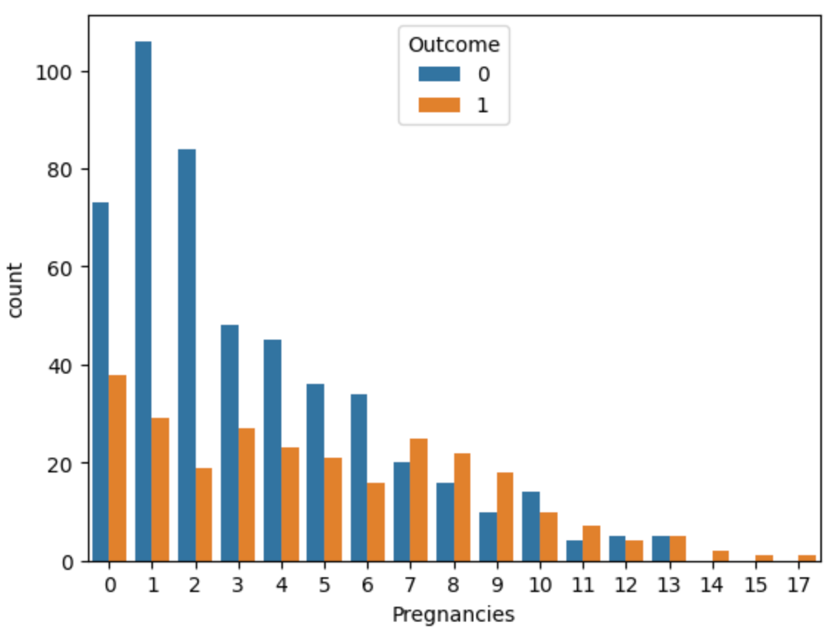

- pregancy_data=data.groupby(['Pregnancies','Outcome'])['Outcome'].count sns.barplot(data=pregancy_data,x='Pregnancies',y='count',hue='Outcome')
- pregancy_data=data.value_counts(['Pregnancies','Outcome'])['Outcome'].count().reset_index(name="count") sns.barplot(data=pregancy_data,x='Pregnancies',y='count',hue='Outcome')
- pregancy_data=data.groupby(['Pregnancies','Outcome'])['Outcome'].count().reset_index(name="count") sns.barplot(data=pregancy_data,x='Pregnancies',y='count',hue='Outcome')
- pregancy_data=data.groupby(['Pregnancies','Outcome']).count().reset_index(name="count") sns.barplot(data=pregancy_data,x='Pregnancies',y='count',hue='Outcome')

In [201]:
pregancy_data=diabetics.groupby(['Pregnancies','Outcome'])['Outcome'].count().reset_index()
sns.barplot(data=pregancy_data)

ValueError: cannot insert Outcome, already exists

In [204]:
diabetics['Pregnancies'].value_counts()

,count
Pregnancies,
1,135
0,111
2,103
3,75
4,68
5,57
6,50
7,45
8,38


In [207]:
np.sort(diabetics['Pregnancies'].unique())

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 17])

In [202]:
diabetics.groupby(['Pregnancies','Outcome'])['Outcome'].count()

Pregnancies  Outcome
0            0           73
             1           38
1            0          106
             1           29
2            0           84
             1           19
3            0           48
             1           27
4            0           45
             1           23
5            0           36
             1           21
6            0           34
             1           16
7            0           20
             1           25
8            0           16
             1           22
9            0           10
             1           18
10           0           14
             1           10
11           0            4
             1            7
12           0            5
             1            4
13           0            5
             1            5
14           1            2
15           1            1
17           1            1
Name: Outcome, dtype: int64

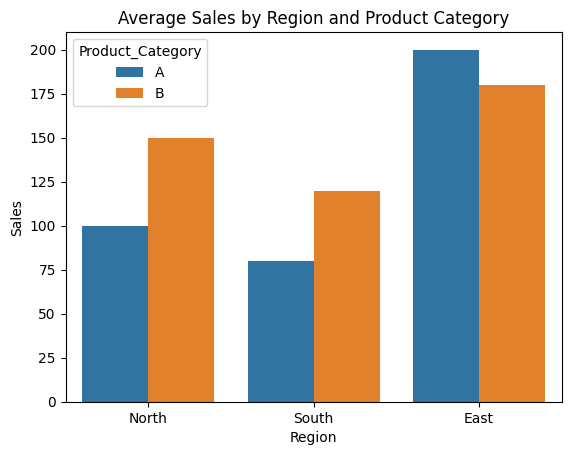

In [234]:
# Create a sample DataFrame
data1 = {
    'Region': ['North', 'North', 'South', 'South', 'East', 'East'],
    'Product_Category': ['A', 'B', 'A', 'B', 'A', 'B'],
    'Sales': [100, 150, 80, 120, 200, 180]
}
df1 = pd.DataFrame(data1)

# Create a barplot with 'Region' on x-axis and 'Product_Category' as hue
sns.barplot(data=df1, x='Region', y='Sales', hue='Product_Category')
plt.title('Average Sales by Region and Product Category')
plt.show()

In [235]:
data = diabetics.copy()

In [215]:
pregancy_data=diabetics.value_counts(['Pregnancies','Outcome'])['Outcome'].count().reset_index(name="count")
sns.barplot(data=pregancy_data,x='Pregnancies',y='count',hue='Outcome')

KeyError: 'Outcome'

In [217]:
diabetics.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [218]:
print(diabetics.value_counts())

Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin  BMI   DiabetesPedigreeFunction  Age  Outcome
12           140      82             43             325      39.2  0.528                     58   1          1
             121      78             17             0        26.5  0.259                     62   0          1
             106      80             0              0        23.6  0.137                     44   0          1
             100      84             33             105      30.0  0.488                     46   0          1
             92       62             7              258      27.6  0.926                     44   1          1
                                                                                                            ..
0            78       88             29             40       36.9  0.434                     21   0          1
             74       52             10             36       27.8  0.269                     22   0          1
      

In [219]:
diabetics.value_counts(['Pregnancies','Outcome'])

,,count
Pregnancies,Outcome,
1,0,106
2,0,84
0,0,73
3,0,48
4,0,45
0,1,38
5,0,36
6,0,34
1,1,29


In [221]:
pregancy_data=diabetics.groupby(['Pregnancies','Outcome']).count().reset_index(name="count")
sns.barplot(data=pregancy_data,x='Pregnancies',y='count',hue='Outcome')

TypeError: DataFrame.reset_index() got an unexpected keyword argument 'name'

<Axes: xlabel='Pregnancies', ylabel='count'>

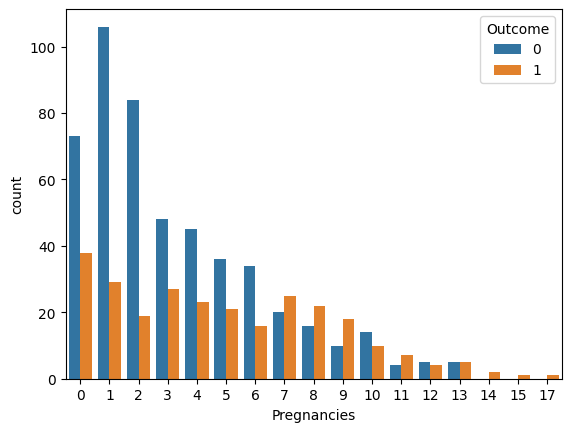

In [222]:
pregancy_data=diabetics.groupby(['Pregnancies','Outcome'])['Outcome'].count().reset_index(name="count")
sns.barplot(data=pregancy_data,x='Pregnancies',y='count',hue='Outcome')

<Axes: xlabel='Pregnancies', ylabel='count'>

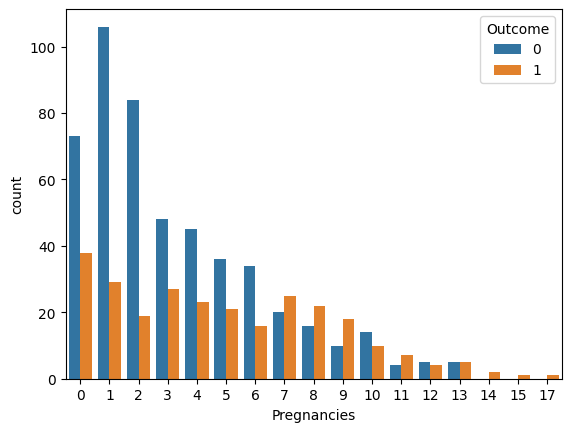

In [224]:
sns.countplot(data=diabetics, x='Pregnancies', hue='Outcome')


In [227]:
diabetics.groupby(['Pregnancies', 'Outcome']).size()

Pregnancies  Outcome
0            0           73
             1           38
1            0          106
             1           29
2            0           84
             1           19
3            0           48
             1           27
4            0           45
             1           23
5            0           36
             1           21
6            0           34
             1           16
7            0           20
             1           25
8            0           16
             1           22
9            0           10
             1           18
10           0           14
             1           10
11           0            4
             1            7
12           0            5
             1            4
13           0            5
             1            5
14           1            2
15           1            1
17           1            1
dtype: int64

In [229]:
diabetics.groupby(['Pregnancies','Outcome'])

In [231]:
diabetics.groupby(['Pregnancies','Outcome'])['Outcome']

In [232]:
diabetics.groupby(['Pregnancies','Outcome'])['Outcome'].count()

Pregnancies  Outcome
0            0           73
             1           38
1            0          106
             1           29
2            0           84
             1           19
3            0           48
             1           27
4            0           45
             1           23
5            0           36
             1           21
6            0           34
             1           16
7            0           20
             1           25
8            0           16
             1           22
9            0           10
             1           18
10           0           14
             1           10
11           0            4
             1            7
12           0            5
             1            4
13           0            5
             1            5
14           1            2
15           1            1
17           1            1
Name: Outcome, dtype: int64

In [233]:
diabetics.groupby(['Pregnancies','Outcome']).count()

Glucose  BloodPressure  SkinThickness  Insulin  BMI  \
Pregnancies Outcome                                                        
0           0             73             73             73       73   73   
            1             38             38             38       38   38   
1           0            106            106            106      106  106   
            1             29             29             29       29   29   
2           0             84             84             84       84   84   
            1             19             19             19       19   19   
3           0             48             48             48       48   48   
            1             27             27             27       27   27   
4           0             45             45             45       45   45   
            1             23             23             23       23   23   
5           0             36             36             36       36   36   
            1             21             21             21       21   21   
6           0             34             34             34       34   34   
            1             16             16             16       16   16   
7           0             20             20             20       20   20   
            1             25             25             25       25   25   
8           0             16             16             16       16   16   
            1             22             22             22       22   22   
9           0             10             10             10       10   10   
            1             18             18             18       18   18   
10          0             14             14             14       14   14   
            1             10             10             10       10   10   
11          0              4              4              4        4    4   
            1              7              7              7        7    7   
12          0              5              5              5        5    5   
            1              4              4              4        4    4   
13          0              5              5              5        5    5   
            1              5              5              5        5    5   
14          1              2              2              2        2    2   
15          1              1              1              1        1    1   
17          1              1              1              1        1    1   

                     DiabetesPedigreeFunction  Age  
Pregnancies Outcome                                 
0           0                              73   73  
            1                              38   38  
1           0                             106  106  
            1                              29   29  
2           0                              84   84  
            1                              19   19  
3           0                              48   48  
            1                              27   27  
4           0                              45   45  
            1                              23   23  
5           0                              36   36  
            1                              21   21  
6           0                              34   34  
            1                              16   16  
7           0                              20   20  
            1                              25   25  
8           0                              16   16  
            1                              22   22  
9           0                              10   10  
            1                              18   18  
10          0                              14   14  
            1                              10   10  
11          0                               4    4  
            1                               7    7  
12          0                               5    5  
            1                               4    4  
13          0               

In [236]:
diabetics.groupby(['Pregnancies', 'Outcome']).columns

AttributeError: 'DataFrameGroupBy' object has no attribute 'columns'

In [239]:
diabetics.groupby(['Pregnancies','Outcome'], as_index=False).count()

,Pregnancies,Outcome,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0,0,73,73,73,73,73,73,73
1,0,1,38,38,38,38,38,38,38
2,1,0,106,106,106,106,106,106,106
3,1,1,29,29,29,29,29,29,29
4,2,0,84,84,84,84,84,84,84
5,2,1,19,19,19,19,19,19,19
6,3,0,48,48,48,48,48,48,48
7,3,1,27,27,27,27,27,27,27
8,4,0,45,45,45,45,45,45,45
9,4,1,23,23,23,23,23,23,23


In [240]:
diabetics.groupby(['Pregnancies','Outcome'], as_index=False)['Outcome'].count()

,Pregnancies,Outcome
0,0,73
1,0,38
2,1,106
3,1,29
4,2,84
5,2,19
6,3,48
7,3,27
8,4,45
9,4,23


In [241]:
# option 1 - count should be a fucn call with ()
pregancy_data=data.groupby(['Pregnancies','Outcome'])['Outcome'].count
sns.barplot(data=pregancy_data,x='Pregnancies',y='count',hue='Outcome')


TypeError: Data source must be a DataFrame or Mapping, not <class 'method'>.

In [247]:
data.value_counts(['Pregnancies','Outcome']) # returns series,

,,count
Pregnancies,Outcome,
1,0,106
2,0,84
0,0,73
3,0,48
4,0,45
0,1,38
5,0,36
6,0,34
1,1,29


value_counts() returns a Series where the index is the combination of columns, not a DataFrame


After value_counts(), there is no column named 'Outcome' anymore — it’s part of the index


Selecting ['Outcome'] will raise an error, because Series indexing works differently

In [248]:
data.value_counts(['Pregnancies','Outcome'])['Outcome']

KeyError: 'Outcome'

reset index name= can be used for series only

In [250]:
data.value_counts(['Pregnancies','Outcome']).reset_index()['Outcome'] # ignores the count fully

,Outcome
0,0
1,0
2,0
3,0
4,0
5,1
6,0
7,0
8,1
9,1


In [251]:
data.value_counts(['Pregnancies','Outcome']).reset_index()['Outcome'].count()
# ignores the count fully, gives only total no. of rows

np.int64(31)

In [254]:
data.value_counts(['Pregnancies','Outcome']).reset_index()

,Pregnancies,Outcome,count
0,1,0,106
1,2,0,84
2,0,0,73
3,3,0,48
4,4,0,45
5,0,1,38
6,5,0,36
7,6,0,34
8,1,1,29
9,3,1,27


In [255]:
data.value_counts(['Pregnancies','Outcome']).reset_index()[['Outcome', 'count']] # here the preg is removed

,Outcome,count
0,0,106
1,0,84
2,0,73
3,0,48
4,0,45
5,1,38
6,0,36
7,0,34
8,1,29
9,1,27


In [242]:
# option 2
pregancy_data=data.value_counts(['Pregnancies','Outcome'])['Outcome'].count().reset_index(name="count")
sns.barplot(data=pregancy_data,x='Pregnancies',y='count',hue='Outcome')


KeyError: 'Outcome'

<Axes: xlabel='Pregnancies', ylabel='count'>

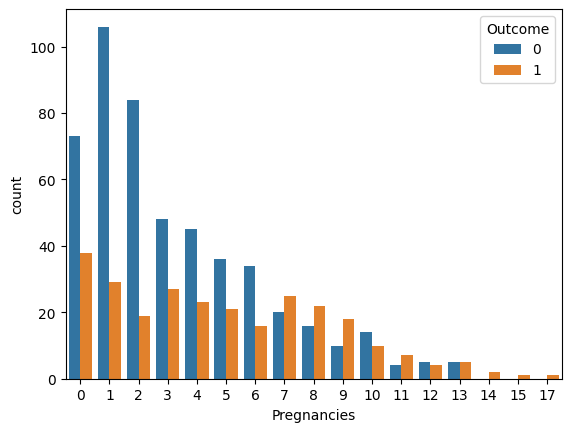

In [256]:
# corrected version of option 2

pregnancy_data = data.value_counts(['Pregnancies','Outcome']).reset_index(name='count') #name is already count only
sns.barplot(data=pregnancy_data, x='Pregnancies', y='count', hue='Outcome')

<Axes: xlabel='Pregnancies', ylabel='count'>

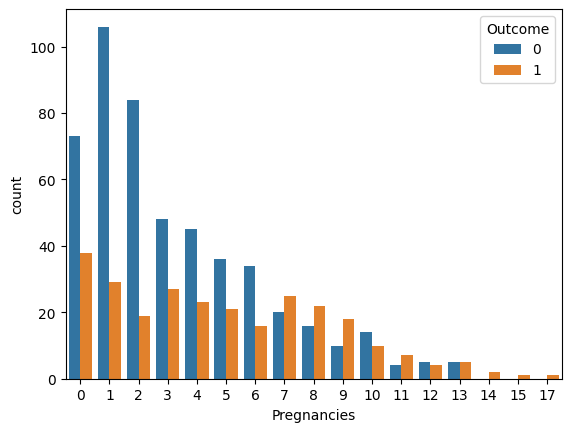

In [257]:
pregnancy_data = data.value_counts(['Pregnancies','Outcome']).reset_index() #name is already count only
sns.barplot(data=pregnancy_data, x='Pregnancies', y='count', hue='Outcome')

<Axes: xlabel='Pregnancies', ylabel='count'>

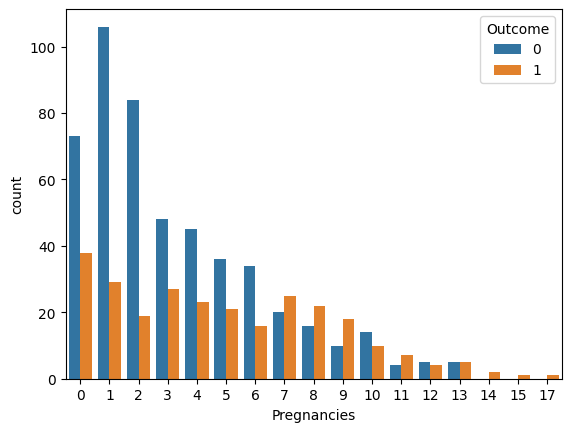

In [258]:
# option 3

pregancy_data=data.groupby(['Pregnancies','Outcome'])['Outcome'].count().reset_index(name="count")
sns.barplot(data=pregancy_data,x='Pregnancies',y='count',hue='Outcome')

option 3 is correct answer

pregancy_data=data.groupby(['Pregnancies','Outcome'])['Outcome'].count().reset_index(name="count")

sns.barplot(data=pregancy_data,x='Pregnancies',y='count',hue='Outcome')

In [259]:
# option 4

pregancy_data=data.groupby(['Pregnancies','Outcome']).count().reset_index(name="count")
# reset index name= not in df
sns.barplot(data=pregancy_data,x='Pregnancies',y='count',hue='Outcome')

TypeError: DataFrame.reset_index() got an unexpected keyword argument 'name'

In [260]:
data.groupby(['Pregnancies','Outcome']).count()

Glucose  BloodPressure  SkinThickness  Insulin  BMI  \
Pregnancies Outcome                                                        
0           0             73             73             73       73   73   
            1             38             38             38       38   38   
1           0            106            106            106      106  106   
            1             29             29             29       29   29   
2           0             84             84             84       84   84   
            1             19             19             19       19   19   
3           0             48             48             48       48   48   
            1             27             27             27       27   27   
4           0             45             45             45       45   45   
            1             23             23             23       23   23   
5           0             36             36             36       36   36   
            1             21             21             21       21   21   
6           0             34             34             34       34   34   
            1             16             16             16       16   16   
7           0             20             20             20       20   20   
            1             25             25             25       25   25   
8           0             16             16             16       16   16   
            1             22             22             22       22   22   
9           0             10             10             10       10   10   
            1             18             18             18       18   18   
10          0             14             14             14       14   14   
            1             10             10             10       10   10   
11          0              4              4              4        4    4   
            1              7              7              7        7    7   
12          0              5              5              5        5    5   
            1              4              4              4        4    4   
13          0              5              5              5        5    5   
            1              5              5              5        5    5   
14          1              2              2              2        2    2   
15          1              1              1              1        1    1   
17          1              1              1              1        1    1   

                     DiabetesPedigreeFunction  Age  
Pregnancies Outcome                                 
0           0                              73   73  
            1                              38   38  
1           0                             106  106  
            1                              29   29  
2           0                              84   84  
            1                              19   19  
3           0                              48   48  
            1                              27   27  
4           0                              45   45  
            1                              23   23  
5           0                              36   36  
            1                              21   21  
6           0                              34   34  
            1                              16   16  
7           0                              20   20  
            1                              25   25  
8           0                              16   16  
            1                              22   22  
9           0                              10   10  
            1                              18   18  
10          0                              14   14  
            1                              10   10  
11          0                               4    4  
            1                               7    7  
12          0                               5    5  
            1                               4    4  
13          0               

16. Answer -

pregancy_data=data.groupby(['Pregnancies','Outcome'])['Outcome'].count().reset_index(name="count")

sns.barplot(data=pregancy_data,x='Pregnancies',y='count',hue='Outcome')

17) Which column has the highest entropy excluding the target column Outcome in the original data?
- DiabetesPedigreeFunction
- BMI
- Pregnancies
- Insulin

In [301]:
diabetics.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [299]:
diabetics.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [300]:
entropy_cols = ['DiabetesPedigreeFunction', 'BMI', 'Pregnancies', 'Insulin']

In [306]:
entropy_map = {}
for col in diabetics.columns:
  col_probs = diabetics[col].value_counts(normalize=True)
  col_entropy = -np.sum(col_probs * np.log2(col_probs))
  entropy_map[col] = col_entropy

In [307]:
entropy_map

{'Pregnancies': np.float64(3.482048096030514),
 'Glucose': np.float64(6.751021001710518),
 'BloodPressure': np.float64(4.792469587589406),
 'SkinThickness': np.float64(4.5855913814785465),
 'Insulin': np.float64(4.68158954287621),
 'BMI': np.float64(7.5937573506351255),
 'DiabetesPedigreeFunction': np.float64(8.828504831523789),
 'Age': np.float64(5.028842203274248),
 'Outcome': np.float64(0.9331343166407831)}

In [308]:
entropy_series = pd.Series(entropy_map)

In [313]:
entropy_series.sort_values(ascending=False)

,0
DiabetesPedigreeFunction,8.828505
BMI,7.593757
Glucose,6.751021
Age,5.028842
BloodPressure,4.792470
Insulin,4.681590
SkinThickness,4.585591
Pregnancies,3.482048
Outcome,0.933134


In [312]:
entropy_series[entropy_cols].sort_values()

,0
Pregnancies,3.482048
Insulin,4.681590
BMI,7.593757
DiabetesPedigreeFunction,8.828505


In [314]:
entropy_series[entropy_cols].max()

8.828504831523789

In [316]:
entropy_series[entropy_cols].idxmax()

'DiabetesPedigreeFunction'

17. Answer - DiabetesPedigreeFunction

18) Which column is considered as the root node of the decision tree using Information Gain in the original data?
- BMI
- DiabetesPedigreeFunction
- BloodPressure
- Glucose

Here parent will become target coln, so entropy of parent is entropy of target (outcome)

[information gain in decison tree - medium.com](https://medium.datadriveninvestor.com/decision-tree-algorithm-with-hands-on-example-e6c2afb40d38)

in the above artice, we can clearly see that entropy is calculated based on target column Yes/no only. no matter what stage we are in tree, entropy always calculated based on target column

initially parent is whole data.

next split, parent becomes a subset of data

in both we have to see how many yes/no in target column

#### IG scores for 1st root node, consider whole data as parent

# Entropy of target (Outcome)

In [327]:
target_entropy1 = entropy1(diabetics['Outcome'])
print("Target Entropy:", target_entropy1)

Target Entropy: 0.9331343166407831


In [324]:
entropy(diabetics['Outcome'].value_counts(normalize=True), base=2)

np.float64(0.9331343166407832)

In [325]:
np.unique(diabetics['Outcome'], return_counts=True)

(array([0, 1]), array([500, 268]))

In [326]:
def entropy_series(series1):
  probs = series1.value_counts(normalize=True)
  return -np.sum(probs * np.log2(probs))

In [329]:
# Entropy of target (Outcome)

target_entropy = entropy_series(diabetics['Outcome'])
print("Target Entropy:", target_entropy)

Target Entropy: 0.9331343166407831


In [330]:
for val, subset in diabetics.groupby('Outcome'):
  print(val)
  print(subset)

0
     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
1              1       85             66             29        0  26.6   
3              1       89             66             23       94  28.1   
5              5      116             74              0        0  25.6   
7             10      115              0              0        0  35.3   
10             4      110             92              0        0  37.6   
..           ...      ...            ...            ...      ...   ...   
762            9       89             62              0        0  22.5   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  Outcome  
1                       0.351   31        0  
3                

In [332]:
# Information Gain for each feature
ig_scores = {}

for col in diabetics.columns:
  if col == 'Outcome':
    continue  # skip target

  # Weighted average entropy after splitting on this feature
  weighted_entropy = 0
  for val, subset in diabetics.groupby(col):
    weighted_entropy += (len(subset) / len(diabetics)) * entropy_series(subset['Outcome'])

  ig = target_entropy - weighted_entropy
  ig_scores[col] = ig

# Convert to Series for easy viewing
ig_series = pd.Series(ig_scores).sort_values(ascending=False)
print("\nInformation Gain per Feature:\n", ig_series)

# Root node = feature with max IG
print("\nRoot node should be:", ig_series.idxmax())



Information Gain per Feature:
 DiabetesPedigreeFunction    0.650918
BMI                         0.343811
Glucose                     0.304201
Insulin                     0.277095
Age                         0.140941
SkinThickness               0.081664
Pregnancies                 0.061825
BloodPressure               0.059310
dtype: float64

Root node should be: DiabetesPedigreeFunction


In [340]:
# Target entropy
target_entropy = entropy_series(diabetics['Outcome'])
print("Target Entropy:", target_entropy)

# Features to check
features = ['BMI', 'DiabetesPedigreeFunction', 'BloodPressure', 'Glucose']

ig_scores = {}

# Discretize continuous features into 5 bins for simplicity
for col in features:
  # bin the feature
  binned = pd.qcut(diabetics[col], q=5, duplicates='drop')

  # Weighted entropy after splitting
  weighted_entropy = 0
  for val, subset in diabetics.groupby(binned):
    weighted_entropy += (len(subset)/len(diabetics)) * entropy_series(subset['Outcome'])

  ig = target_entropy - weighted_entropy
  ig_scores[col] = ig

# Convert to Series and sort
ig_series = pd.Series(ig_scores).sort_values(ascending=False)
print("\nInformation Gain per Feature:\n", ig_series)

# Feature with max IG = root node
print("\nRoot node should be:", ig_series.idxmax())


Target Entropy: 0.9331343166407831

Information Gain per Feature:
 Glucose                     0.169175
BMI                         0.084009
DiabetesPedigreeFunction    0.024978
BloodPressure               0.018589
dtype: float64

Root node should be: Glucose


/tmp/ipython-input-4226125078.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for val, subset in diabetics.groupby(binned):
/tmp/ipython-input-4226125078.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for val, subset in diabetics.groupby(binned):
/tmp/ipython-input-4226125078.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for val, subset in diabetics.groupby(binned):
/tmp/ipython-input-4226125078.py:17: 

**Correct answer is glucose**

binned only gives correct answer

For **continuous features**, Information Gain depends on **how you split the feature**.

---

##### Why `binned` matters:

1. **IG is defined for discrete splits** (like categories).
2. If you feed raw continuous values directly into `groupby`, you get **one group per unique value**, which is almost every row → each subset is tiny → **weighted entropy ≈ 0** → IG calculation is wrong.
3. **Binning** (like `pd.qcut`) groups values into **intervals**, so each group has enough rows → meaningful IG.

---

##### Alternatives to binning:

* Use **decision tree algorithm** (like `DecisionTreeClassifier`) which automatically finds **optimal split thresholds** for continuous features.
* Manually try **different thresholds** and pick the one that maximizes IG.

---

##### ✅ Rule of Thumb:

* **Discrete/categorical features** → can calculate IG directly.
* **Continuous features** → must **bin or find thresholds**; otherwise IG results will be misleading.

---


---

##### **1️⃣ Why binning changes Information Gain**

Suppose we have a continuous feature `Glucose` with values like `[85, 90, 110, 120, 145, 180]` and target `Outcome`.

* **Without binning** (`groupby` on raw values):

  * Each unique glucose value becomes **its own group**.
  * Most groups have only 1–2 rows → weighted entropy ≈ 0.
  * The calculated IG is **wrongly high for uninformative features** or misleading.

* **With binning** (`pd.qcut` into 5 bins):

  * Values are grouped into intervals, e.g., `80–100`, `101–120`, etc.
  * Each bin has **enough rows** → weighted entropy is meaningful.
  * IG now **correctly reflects how informative the feature is**.

⚡ **Takeaway:** For continuous features, you **must discretize or find thresholds**, otherwise IG computation is invalid.

---

##### **2️⃣ Explaining the line of code**

```python
binned = pd.qcut(diabetics[col], q=5, duplicates='drop')
```

* `pd.qcut()` → **quantile-based discretization**

  * `diabetics[col]` → the feature column (e.g., Glucose)
  * `q=5` → divide into **5 bins with roughly equal number of rows**
  * `duplicates='drop'` → if some bins have the same boundary (rare), drop them

* Example: Glucose values `[85, 90, 110, 120, 145, 180]` with `q=3` might become:

```
(84.999, 110.0] → bin 1
(110.0, 145.0] → bin 2
(145.0, 180.0] → bin 3
```

* Now `groupby(binned)` will **group all rows in each interval** → weighted entropy is meaningful.

---

##### ✅ Summary

1. Continuous features **cannot be grouped directly** for IG calculation.
2. **Binning** converts continuous data into categories.
3. After binning, `groupby(binned)` gives **child nodes** for IG calculation.
4. This is why your answer changes with and without binning — without binning, the IG calculation is misleading.

---



```python
for val, subset in diabetics.groupby(binned, observed=True):
    # your code
```

observed=True

This will group only the bins that actually have data, which is usually what you want.

No change in your IG calculation result.

In [345]:
# using 10 bins


# Features to check
features = ['BMI', 'DiabetesPedigreeFunction', 'BloodPressure', 'Glucose']

ig_scores = {}

# Discretize continuous features into 5 bins for simplicity
for col in features:
  # bin the feature
  binned = pd.qcut(diabetics[col], q=10, duplicates='drop')

  # Weighted entropy after splitting
  weighted_entropy = 0
  for val, subset in diabetics.groupby(binned, observed=True):
    weighted_entropy += (len(subset)/len(diabetics)) * entropy_series(subset['Outcome'])

  ig = target_entropy - weighted_entropy
  ig_scores[col] = ig

# Convert to Series and sort
ig_series = pd.Series(ig_scores).sort_values(ascending=False)
print("\nInformation Gain per Feature:\n", ig_series)

# Feature with max IG = root node
print("\nRoot node should be:", ig_series.idxmax())



Information Gain per Feature:
 Glucose                     0.183271
BMI                         0.094083
DiabetesPedigreeFunction    0.028394
BloodPressure               0.027285
dtype: float64

Root node should be: Glucose


In [344]:
# Features and target
X_diabetics_root = diabetics[['BMI', 'DiabetesPedigreeFunction', 'BloodPressure', 'Glucose']]
y_diabetics_root = diabetics['Outcome']

# Fit decision tree (use entropy as criterion)
diabetics_root = DecisionTreeClassifier(criterion='entropy', max_depth=1)  # max_depth=1 gives the root only
diabetics_root.fit(X_diabetics_root, y_diabetics_root)

# Root node feature
X_diabetics_root.columns[diabetics_root.tree_.feature[0]]

'Glucose'

In [346]:
binned

,Glucose
0,"(147.0, 167.0]"
1,"(-0.001, 85.0]"
2,"(167.0, 199.0]"
3,"(85.0, 95.0]"
4,"(134.0, 147.0]"
...,...
763,"(95.0, 102.0]"
764,"(117.0, 125.0]"
765,"(117.0, 125.0]"
766,"(125.0, 134.0]"


In [348]:
len(binned.unique())

10

In [349]:
binned.unique()

[(147.0, 167.0], (-0.001, 85.0], (167.0, 199.0], (85.0, 95.0], (134.0, 147.0], (109.0, 117.0], (117.0, 125.0], (95.0, 102.0], (102.0, 109.0], (125.0, 134.0]]
Categories (10, interval[float64, right]): [(-0.001, 85.0] < (85.0, 95.0] < (95.0, 102.0] <
                                            (102.0, 109.0] ... (125.0, 134.0] < (134.0, 147.0] <
                                            (147.0, 167.0] < (167.0, 199.0]]

##### **1️⃣ Passing a column name vs passing a Series to `groupby`**

**Normal usage:**

```python
df.groupby('Glucose')
```

* Pandas groups by the **values in the column `'Glucose'`** of the DataFrame.
* `'Glucose'` must exist as a column in `df`.

---

**Using a Series:**

```python
binned = pd.qcut(df['Glucose'], q=5, duplicates='drop')
df.groupby(binned)
```

* Here, `binned` is **not a column in the DataFrame**; it’s a **separate Pandas Series** with the same length as `df`.
* `groupby` allows you to pass **any array-like / Series / list of labels** to define groups.
* Each element in `binned` specifies **which group that row belongs to**.

---

##### **2️⃣ Why we pass the series**

* For **continuous features**, we want to group **by intervals**, not raw values.
* `binned` contains **interval labels** from `pd.qcut`.
* Passing the series directly lets us group **rows according to the bin they fall into**, even though this “bin column” is not actually in the DataFrame.
---

✅ **Key takeaway:**

> `groupby` can take a Series directly. This is useful when the grouping logic **doesn’t exist as a DataFrame column**, like discretized bins for continuous features.

---


Correct ✅ — **for calculating entropy of a single column (like the target), you do NOT need to bin numeric columns.**

---

### Explanation:

1. **Entropy formula**:
   $
   H(Y) = -\sum_i p_i \log_2(p_i)
   $

* `p_i` = probability of each unique value in the series.

2. **What matters**:

* Entropy only needs **counts of unique values** in that series.
* It doesn’t matter if the series is numeric or categorical — Pandas’ `value_counts()` works for both.

---
Entropy :

* Works fine without binning.
* Result: entropy = uncertainty in the distribution of `x`.

---

### ⚡ Key difference:

| Use case                                               | Binning needed?          |
| ------------------------------------------------------ | ------------------------ |
| **Entropy of target column**                           | No                       |
| **Information Gain / splitting on continuous feature** | Yes (or find thresholds) |

* **Why**: For IG, you need **groups of the feature** to calculate child entropies.
* For **target entropy**, you’re just counting class distribution — no groups needed.

---

If you want, I can **illustrate with the diabetes dataset**: show entropy of `Outcome` (no binning) vs trying to compute IG on `Glucose` (needs binning).

Do you want me to do that?


18. Answer - Glucose

19) Provided the probability distribution is known, determine which column has the lowest gini index excluding the target column Outcome in the original data?
- DiabetesPedigreeFunction
- Insulin
- Pregnancies
- BMI

##### **1️⃣ Gini Index Definition**

Gini Index measures **impurity** of a set (how mixed the classes are).

* Lower Gini → purer node (more dominated by one class)
* Higher Gini → more mixed classes

For a variable (Y) with classes (c_1, c_2, ..., c_k), Gini Index is:


$Gini(Y) = 1 - \sum_{i=1}^{k} p_i^2$


Where:

* (p_i) = probability of class (i) in the set

---

##### **2️⃣ Examples**

* Pure node (all class 1): (p_1=1, p_0=0)
  [
  Gini = 1 - (1^2 + 0^2) = 0
  ]

* Mixed node (50%-50%): (p_1=0.5, p_0=0.5)
  [
  Gini = 1 - (0.5^2 + 0.5^2) = 0.5
  ]

* Mixed node (70%-30%): (p_1=0.7, p_0=0.3)
  [
  Gini = 1 - (0.7^2 + 0.3^2) = 0.42
  ]

---

##### **3️⃣ Gini vs Entropy**

| Metric     | Range       | Interpretation                 |
| ---------- | ----------- | ------------------------------ |
| Entropy    | 0 – log₂(k) | 0 = pure, max = most uncertain |
| Gini Index | 0 – 1       | 0 = pure, 1 = most mixed       |

---

##### **4️⃣ How to find lowest Gini for a feature**

1. Compute **weighted Gini** for splitting the target `Outcome` by each feature:


$Gini(Y|X) = \sum_{v \in values(X)} \frac{|Y_v|}{|Y|} \left(1 - \sum_{i} p_{i|v}^2\right)$


* (Y_v) = subset of rows where feature (X = v)
* (p_{i|v}) = probability of class (i) in that subset

2. Feature with **lowest Gini after split** → best feature (purest children).

---

For your question, you would calculate **Gini for each of these features (excluding Outcome)** and see which one has the **lowest value**.

---


In [350]:
# Features and target
X_diabetics_gini = diabetics[['DiabetesPedigreeFunction', 'Insulin', 'Pregnancies', 'BMI']]
y_diabetics_gini = diabetics['Outcome']

# Fit decision tree (use entropy as criterion)
diabetics_gini = DecisionTreeClassifier(criterion='gini', max_depth=1)  # max_depth=1 gives the root only
diabetics_gini.fit(X_diabetics_gini, y_diabetics_gini)

# Root node feature
X_diabetics_gini.columns[diabetics_gini.tree_.feature[0]]

'BMI'

In [352]:
diabetics_gini.tree_

In [358]:
# without using binned
features = ['DiabetesPedigreeFunction', 'Insulin', 'Pregnancies', 'BMI']
target = 'Outcome'

# Helper function: weighted Gini
def weighted_gini_no_bin(df, feature, target):
  gini_total = 0
  total_rows = len(df)

  for val, subset in df.groupby(feature, observed=True):
    p = subset[target].value_counts(normalize=True)
    gini_subset = 1 - np.sum(p**2)
    gini_total += (len(subset) / total_rows) * gini_subset

  return gini_total

# Compute weighted Gini for all features
gini_scores_no_bin = {}
for f in features:
  gini_scores_no_bin[f] = weighted_gini_no_bin(diabetics, f, target)

# Convert to Series and sort
gini_series_no_bin = pd.Series(gini_scores_no_bin).sort_values()
print("Weighted Gini WITHOUT BIN per feature:\n", gini_series_no_bin)
print("\nWITHOUT BIN Root node feature should be:", gini_series_no_bin.index[0])

Weighted Gini WITHOUT BIN per feature:
 DiabetesPedigreeFunction    0.139019
BMI                         0.284888
Insulin                     0.319617
Pregnancies                 0.416157
dtype: float64

WITHOUT BIN Root node feature should be: DiabetesPedigreeFunction


In [366]:
# Features and target
features = ['DiabetesPedigreeFunction', 'Insulin', 'Pregnancies', 'BMI']
target = 'Outcome'

# Helper function: weighted Gini
def weighted_gini(df, feature, target):
  # Bin the feature into 5 categories (you can adjust bins)
  binned = pd.qcut(df[feature], q=5, duplicates='drop')

  gini_total = 0
  total_rows = len(df)

  for val, subset in df.groupby(binned, observed=True):
    p = subset[target].value_counts(normalize=True)
    gini_subset = 1 - np.sum(p**2)
    gini_total += (len(subset) / total_rows) * gini_subset

  return gini_total

# Compute weighted Gini for all features
gini_scores = {}
for f in features:
  gini_scores[f] = weighted_gini(diabetics, f, target)

# Convert to Series and sort
gini_series = pd.Series(gini_scores).sort_values()
print("Weighted Gini per feature:\n", gini_series)
print("\nRoot node feature should be:", gini_series.index[0])

Weighted Gini per feature:
 BMI                         0.407241
Pregnancies                 0.426977
DiabetesPedigreeFunction    0.438750
Insulin                     0.440183
dtype: float64

Root node feature should be: BMI


In [367]:
pd.Series(gini_scores).idxmin()

'BMI'

In [368]:
def best_gini_threshold(df, feature, target):
  values = df[feature].sort_values().unique()
  min_gini = float('inf')
  best_thresh = None

  for t in values:
    left = df[df[feature] <= t]
    right = df[df[feature] > t]

    # Weighted Gini
    total = len(df)
    gini_left = 1 - np.sum((left[target].value_counts(normalize=True)**2))
    gini_right = 1 - np.sum((right[target].value_counts(normalize=True)**2))
    weighted_gini = (len(left)/total)*gini_left + (len(right)/total)*gini_right

    if weighted_gini < min_gini:
      min_gini = weighted_gini
      best_thresh = t

  return min_gini, best_thresh

In [369]:
best_gini_scores = {}
for f in features:
  best_gini_scores[f] = best_gini_threshold(diabetics, f, target)

# Convert to Series and sort
best_gini_scores_series = pd.Series(best_gini_scores).sort_values()
print("Weighted Gini per feature:\n", best_gini_scores_series)
print("\nRoot node feature should be:",best_gini_scores_series.index[0])

Weighted Gini per feature:
 BMI                          (0.4115023467836636, 29.8)
Pregnancies                    (0.42873096762190765, 6)
Insulin                       (0.4370040029621336, 120)
DiabetesPedigreeFunction    (0.4410628791154332, 0.527)
dtype: object

Root node feature should be: BMI


Ah, that makes sense. The reason we are **not getting `Insulin`** even after binning is because:

1. **DecisionTreeClassifier doesn’t use fixed bins**. It finds the **exact numeric threshold** that gives the lowest weighted Gini.
2. When you manually bin, you **lose the fine-grained splits**, so another feature (like BMI) might appear to have lower weighted Gini in your calculation.
3. The answer key (`Insulin`) likely assumes either:

   * A specific **preprocessing or binning method**
   * Or it’s just illustrating the concept; in practice, the actual dataset values determine the split.

---

### Options to manually reproduce sklearn behavior:

* Instead of qcut bins, you can **compute weighted Gini for all possible thresholds** of each numeric feature (all unique values).
* Then take the threshold that **minimizes the weighted Gini** for that feature.
* The feature with the **overall lowest weighted Gini** becomes the root node.

---

Here’s a code outline to do that for one feature:

```python
# refer above code for best_gini_threshold
```

* You can run this for all features and see which **feature + threshold** gives the **lowest weighted Gini**.
* That will exactly match what sklearn does for `max_depth=1`.

---


In [370]:
import pandas as pd
import numpy as np

# Features and target
features = ['DiabetesPedigreeFunction', 'Insulin', 'Pregnancies', 'BMI']
target = 'Outcome'

# Function to compute weighted Gini for a given threshold
def weighted_gini_split(df, feature, target, threshold):
    left = df[df[feature] <= threshold]
    right = df[df[feature] > threshold]

    total = len(df)

    # Gini for left
    if len(left) == 0:
        gini_left = 0
    else:
        p_left = left[target].value_counts(normalize=True)
        gini_left = 1 - np.sum(p_left**2)

    # Gini for right
    if len(right) == 0:
        gini_right = 0
    else:
        p_right = right[target].value_counts(normalize=True)
        gini_right = 1 - np.sum(p_right**2)

    # Weighted Gini
    return (len(left)/total)*gini_left + (len(right)/total)*gini_right

# Function to find best threshold for a feature
def best_threshold_for_feature(df, feature, target):
    values = np.sort(df[feature].unique())
    min_gini = float('inf')
    best_thresh = None

    for t in values:
        gini = weighted_gini_split(df, feature, target, t)
        if gini < min_gini:
            min_gini = gini
            best_thresh = t
    return min_gini, best_thresh

# Compute best Gini for all features
results = {}
for f in features:
    gini_val, thresh = best_threshold_for_feature(diabetics, f, target)
    results[f] = (gini_val, thresh)

# Convert to DataFrame for readability
results_df = pd.DataFrame.from_dict(results, orient='index', columns=['Weighted Gini', 'Best Threshold'])
results_df = results_df.sort_values('Weighted Gini')
print(results_df)

# Root node = feature with lowest weighted Gini
root_node = results_df.index[0]
print("\nRoot node feature should be:", root_node)


                          Weighted Gini  Best Threshold
BMI                            0.411502          29.800
Pregnancies                    0.428731           6.000
Insulin                        0.437004         120.000
DiabetesPedigreeFunction       0.441063           0.527

Root node feature should be: BMI


However I get Answer as BMI only

but correct answer as per key is insulin

19. Answer - BMI

19. Correct Answer as per reslts in Quiz - Insulin

20) Consider we have built one decision tree and got AUC-ROC score as 0. Now the model predicts the outcome as 0 for one record, what will be the real outcome for that record?
- 0.5
- 0
- Can’t predict the real outcome.
- 1

If  **decision tree gives an AUC-ROC score of 0**, that is a **very bad and unusual situation**, and here’s what it means:

---

##### 1. What AUC-ROC = 0 means

* **AUC (Area Under the ROC Curve)** measures the ability of a model to **rank positive instances higher than negative ones**.
* A perfect model → AUC = 1
* A model that predicts **randomly** → AUC ≈ 0.5
* **AUC = 0** → the model is **perfectly wrong**:

  * It ranks all positive samples lower than all negative samples.
  * Basically, it predicts the **opposite** of the true labels for all ranking purposes.

---

##### 2. Why it can happen with a decision tree

1. **Target classes are flipped accidentally**

   * You might have swapped 0 and 1 in the target column.
2. **Predicted probabilities are inverted**

   * Some code might give probability for class 0 instead of class 1 when computing ROC.
3. **Model is extremely biased**

   * If the tree only predicts one class and the positive class is always ranked last.
4. **Small dataset or unusual splitting**

   * With very few samples, it’s possible to get all positives ranked below negatives.

---

##### 3. How to fix or check

* Check the **true labels**: `np.unique(y_test)`
* Check the **predicted probabilities**: `y_pred_proba[:,1]` should be for the positive class.
* If the model is inverted, you can **flip the probabilities**: `1 - y_pred_proba[:,1]` and recompute AUC.

---

✅ Key point: **AUC-ROC = 0 doesn’t mean your model is random—it means it’s perfectly wrong in ranking.**

---


In [374]:
from sklearn.metrics import roc_auc_score

# Example dataset (binary classification)
X_eg = np.array([[0], [1], [2], [3]])
y_eg = np.array([0, 0, 1, 1])  # True labels

# Decision tree predicts perfectly opposite of actual
# We'll force predictions to be inverted probabilities
model_eg = DecisionTreeClassifier(max_depth=1)
model_eg.fit(X_eg, 1 - y_eg)  # fitting with flipped target

# Predicted probabilities
y_pred_proba_eg = model_eg.predict_proba(X_eg)[:,1]

# Compute AUC
auc_eg = roc_auc_score(y_eg, y_pred_proba_eg)
print("AUC-ROC (inverted):", auc_eg)  # likely 0

# Fix: flip predicted probabilities
y_pred_proba_flipped_eg = 1 - y_pred_proba_eg
auc_fixed_eg = roc_auc_score(y_eg, y_pred_proba_flipped_eg)
print("AUC-ROC after flipping:", auc_fixed_eg)  # should be 1


AUC-ROC (inverted): 0.0
AUC-ROC after flipping: 1.0


If outcome is 0 as predicted means, actual outcome is 1

20. Answer - 1

21) Use the diabetes.csv data for the following questions, Don’t perform any Data cleaning or pre-processing before answering the question. Perform the below operations in the original data and answer the question. Remove the records with 0 Glucose. Filter the column Glucose having values less than and equal to 75. Now whether the Glucose column with filtered values is considered as leaf node?
- FALSE
- TRUE

In [375]:
diabetics.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [376]:
diabetics_21 = diabetics.copy()

##### Remove the records with 0 Glucose

In [377]:
# Remove the records with 0 Glucose

In [379]:
np.sort(diabetics_21['Glucose'].unique())

array([  0,  44,  56,  57,  61,  62,  65,  67,  68,  71,  72,  73,  74,
        75,  76,  77,  78,  79,  80,  81,  82,  83,  84,  85,  86,  87,
        88,  89,  90,  91,  92,  93,  94,  95,  96,  97,  98,  99, 100,
       101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113,
       114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126,
       127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139,
       140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152,
       153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165,
       166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178,
       179, 180, 181, 182, 183, 184, 186, 187, 188, 189, 190, 191, 193,
       194, 195, 196, 197, 198, 199])

In [382]:
diabetics_21[diabetics_21['Glucose']==0]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
75,1,0,48,20,0,24.7,0.140,22,0
182,1,0,74,20,23,27.7,0.299,21,0
342,1,0,68,35,0,32.0,0.389,22,0
349,5,0,80,32,0,41.0,0.346,37,1
502,6,0,68,41,0,39.0,0.727,41,1


In [384]:
len(diabetics_21[diabetics_21['Glucose']==0])

5

In [389]:
index_glucode_0 = diabetics_21[diabetics_21['Glucose']==0].index

In [390]:
index_glucode_0

Index([75, 182, 342, 349, 502], dtype='int64')

In [391]:
diabetics_21.drop(index_glucode_0, inplace=True) #default axis is 0 to drop rows

In [392]:
diabetics_21.info()

<class 'pandas.core.frame.DataFrame'>
Index: 763 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               763 non-null    int64  
 1   Glucose                   763 non-null    int64  
 2   BloodPressure             763 non-null    int64  
 3   SkinThickness             763 non-null    int64  
 4   Insulin                   763 non-null    int64  
 5   BMI                       763 non-null    float64
 6   DiabetesPedigreeFunction  763 non-null    float64
 7   Age                       763 non-null    int64  
 8   Outcome                   763 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 59.6 KB


In [393]:
# 5 rows dropped

##### Filter the column Glucose having values less than and equal to 75

In [395]:
diabetics_21[diabetics_21['Glucose']<=75]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
47,2,71,70,27,0,28.0,0.586,22,0
55,1,73,50,10,0,23.0,0.248,21,0
62,5,44,62,0,0,25.0,0.587,36,0
76,7,62,78,0,0,32.6,0.391,41,0
81,2,74,0,0,0,0.0,0.102,22,0
97,1,71,48,18,76,20.4,0.323,22,0
146,9,57,80,37,0,32.8,0.096,41,0
174,2,75,64,24,55,29.7,0.370,33,0
183,5,73,60,0,0,26.8,0.268,27,0
234,3,74,68,28,45,29.7,0.293,23,0


In [396]:
filtered_glucose = diabetics_21[diabetics_21['Glucose'] <= 75]['Glucose']


In [397]:
filtered_glucose

,Glucose
47,71
55,73
62,44
76,62
81,74
97,71
146,57
174,75
183,73
234,74


In [399]:
filtered_glucose_outcome = diabetics_21[diabetics_21['Glucose'] <= 75][['Glucose', 'Outcome']]
filtered_glucose_outcome

,Glucose,Outcome
47,71,0
55,73,0
62,44,0
76,62,0
81,74,0
97,71,0
146,57,0
174,75,0
183,73,0
234,74,0


###### 2. Leaf node concept:

* In a **decision tree**, a **leaf node** is a node that **cannot be split further**.

* A node becomes a leaf when:

  1. All the samples in it belong to the **same class**, or
  2. There are no more features to split on, or
  3. Some stopping criterion (like max depth) is reached.

* If the `Glucose` values after filtering still **contain multiple class labels (Outcome = 0 and 1)**, then this node **can still be split** → it is **not a leaf node**.

----

###### ✅ Answer:

* After removing 0 Glucose and filtering <= 75, the Glucose column **still contains both 0 and 1 outcomes**.
* So it **cannot be a leaf node**.


In [400]:
# Outcome values for filtered Glucose
diabetics_filtered = diabetics_21[diabetics_21['Glucose'] <= 75]
print(diabetics_filtered['Outcome'].value_counts())

Outcome
0    25
Name: count, dtype: int64


In [401]:
diabetics_filtered['Outcome'].value_counts()

,count
Outcome,
0,25


In [402]:
entropy_series(diabetics_filtered['Outcome'])

np.float64(-0.0)

In [403]:
entropy_series(diabetics_filtered['Outcome']) == 0

np.True_

Why it shows -0 instead of 0

It’s just a floating point representation.

-0.0 is equivalent to 0.0 in Python.

so, entropy 0, pure node, leaf node

21. Answer - TRUE

22) Use the diabetes.csv data for the following questions, Don’t perform any Data cleaning or pre-processing before answering the question. Perform the below operations in the original data and answer the question. Independent features – Pregnancies & BloodPressure Dependent feature – Outcome Split train and test with split size as 0.2 and random state as 24 Fit the model with random_state=8 and get accuracy with test data. Get the accuracy of 0.59090909. Calculate the precision using the confusion matrix for the developed model?
- 0.56
- 0.38
- 0.74
- 0.41

In [404]:
diabetics_22 = diabetics.copy()

In [406]:
diabetics_22.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


##### Features and target

Independent features – Pregnancies & BloodPressure

Dependent feature – Outcome

In [407]:
X_22 = diabetics_22[['Pregnancies', 'BloodPressure']]

In [408]:
X_22

,Pregnancies,BloodPressure
0,6,72
1,1,66
2,8,64
3,1,66
4,0,40
...,...,...
763,10,76
764,2,70
765,5,72
766,1,60


In [409]:
y_22 = diabetics_22['Outcome']

##### Split train and test with split size as 0.2 and random state as 24

In [410]:
X_train_22, X_test_22, y_train_22, y_test_22 = train_test_split(X_22, y_22, test_size = 0.2, random_state = 24)

In [411]:
X_train_22.shape

(614, 2)

In [412]:
X_test_22.shape

(154, 2)

In [413]:
y_train_22.shape

(614,)

In [414]:
y_test_22.shape

(154,)

##### Fit the model with random_state=8

In [415]:
dt_22 = DecisionTreeClassifier(random_state=8)

In [416]:
dt_22.fit(X_train_22, y_train_22)

DecisionTreeClassifier(random_state=8)

##### get accuracy with test data. Get the accuracy of 0.59090909

In [417]:
y_pred_22 = dt_22.predict(X_test_22)

In [418]:
accuracy_score(y_test_22, y_pred_22)

0.5909090909090909

#####  Calculate the precision using the confusion matrix for the developed model?

In [419]:
cm_22 = confusion_matrix(y_test_22, y_pred_22)

In [420]:
cm_22

array([[74, 24],
       [39, 17]])

In [421]:
# precision without confusion matirx

precision_score(y_test_22, y_pred_22)

0.4146341463414634

In [423]:
TN_22, FP_22, FN_22, TP_22 = cm_22.flatten()

In [426]:
precision_22 = (TP_22) / (TP_22 + FP_22)

In [427]:
precision_22

np.float64(0.4146341463414634)

22. Answer - 0.41

23) Use the diabetes.csv data for the following questions, Don’t perform any Data cleaning or pre-processing before answering the question. Perform the below operations in the original data and answer the question. Independent features – Insulin & BMI Dependent feature – Outcome Split train and test with split size as 0.2 and random state as 24 Fit the model with random_state=30 and get accuracy with test data. Get the accuracy of 0.6818181818. Calculate the Recall using the confusion matrix for the developed model?
- 0.28
- 0.5
- 0.30
- 0.79

In [428]:
diabetics_23 = diabetics.copy()

##### Features and target

Independent features – Insulin & BMI

Dependent feature – Outcome

In [429]:
X_23 = diabetics_23[['Insulin', 'BMI']]
y_23 = diabetics_23['Outcome']

In [430]:
X_23

,Insulin,BMI
0,0,33.6
1,0,26.6
2,0,23.3
3,94,28.1
4,168,43.1
...,...,...
763,180,32.9
764,0,36.8
765,112,26.2
766,0,30.1


In [431]:
y_23

,Outcome
0,1
1,0
2,1
3,0
4,1
...,...
763,0
764,0
765,0
766,1


##### Split train and test with split size as 0.2 and random state as 24

In [432]:
X_train_23, X_test_23, y_train_23, y_test_23 = train_test_split(X_23, y_23, test_size = 0.2, random_state = 24)

In [433]:
X_train_23

,Insulin,BMI
280,0,37.9
528,188,30.8
569,165,34.3
495,0,26.6
638,91,40.9
...,...,...
145,0,0.0
401,0,24.2
343,0,34.7
192,0,30.4


In [434]:
X_train_23.shape

(614, 2)

In [435]:
y_train_23.shape

(614,)

In [436]:
X_test_23.shape

(154, 2)

In [438]:
y_test_23.shape

(154,)

In [440]:
X_test_23

,Insulin,BMI
313,85,29.5
99,220,49.7
550,0,27.4
334,58,23.9
211,0,42.8
...,...,...
244,194,38.2
398,0,21.1
684,0,0.0
730,79,28.4


##### Fit the model with random_state=30

In [441]:
dt_23 = DecisionTreeClassifier(random_state=30)

In [442]:
dt_23.fit(X_train_23, y_train_23)

DecisionTreeClassifier(random_state=30)

##### get accuracy with test data. Get the accuracy of 0.6818181818

In [443]:
y_pred_23 = dt_23.predict(X_test_23)

In [444]:
accuracy_score(y_test_23, y_pred_23)

0.6818181818181818

##### Calculate the Recall using the confusion matrix for the developed model?

In [445]:
cm_23 = confusion_matrix(y_test_23, y_pred_23)

In [447]:
cm_23

array([[77, 21],
       [28, 28]])

In [446]:
TN_23, FP_23, FN_23, TP_23 = cm_23.flatten()

In [448]:
recall_23 = TP_23 / (TP_23 + FN_23)

In [449]:
recall_23

np.float64(0.5)

In [451]:
# recall without confusion matrix
recall_score(y_test_23, y_pred_23)

0.5

23. Answer - 0.5